<a href="https://colab.research.google.com/github/adiban17/Deep-Learning-Models/blob/main/VGGNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing the Dataset and Data Augmentation**

In [2]:
!unzip -q "/content/drive/MyDrive/NPTEL : Foundations of Deep Learning Concepts and Applications (Datasets)/alzheimer dataset_2.zip" -d /content/dataset_local

In [3]:
!ls -lh /content/dataset_local

total 8.0K
drwxr-xr-x 4 root root 4.0K May 25 20:51 'alzheimer dataset'
drwxr-xr-x 3 root root 4.0K May 26 05:45  __MACOSX


In [4]:
# Suppressing all Warnings

import warnings
warnings.filterwarnings('ignore')

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the paths
train_dir = '/content/dataset_local/alzheimer dataset/train'
test_dir = '/content/dataset_local/alzheimer dataset/test'

# Create an ImageDataGenerator object for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=90,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load the images and labels, ensuring grayscale (1 color channel)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    class_mode='categorical'
)

Found 4647 images belonging to 4 classes.
Found 1230 images belonging to 4 classes.


# **MODEL BUILDING**

## **VGGNet**

### **VGG16 Original**

#### **Model Architecture**

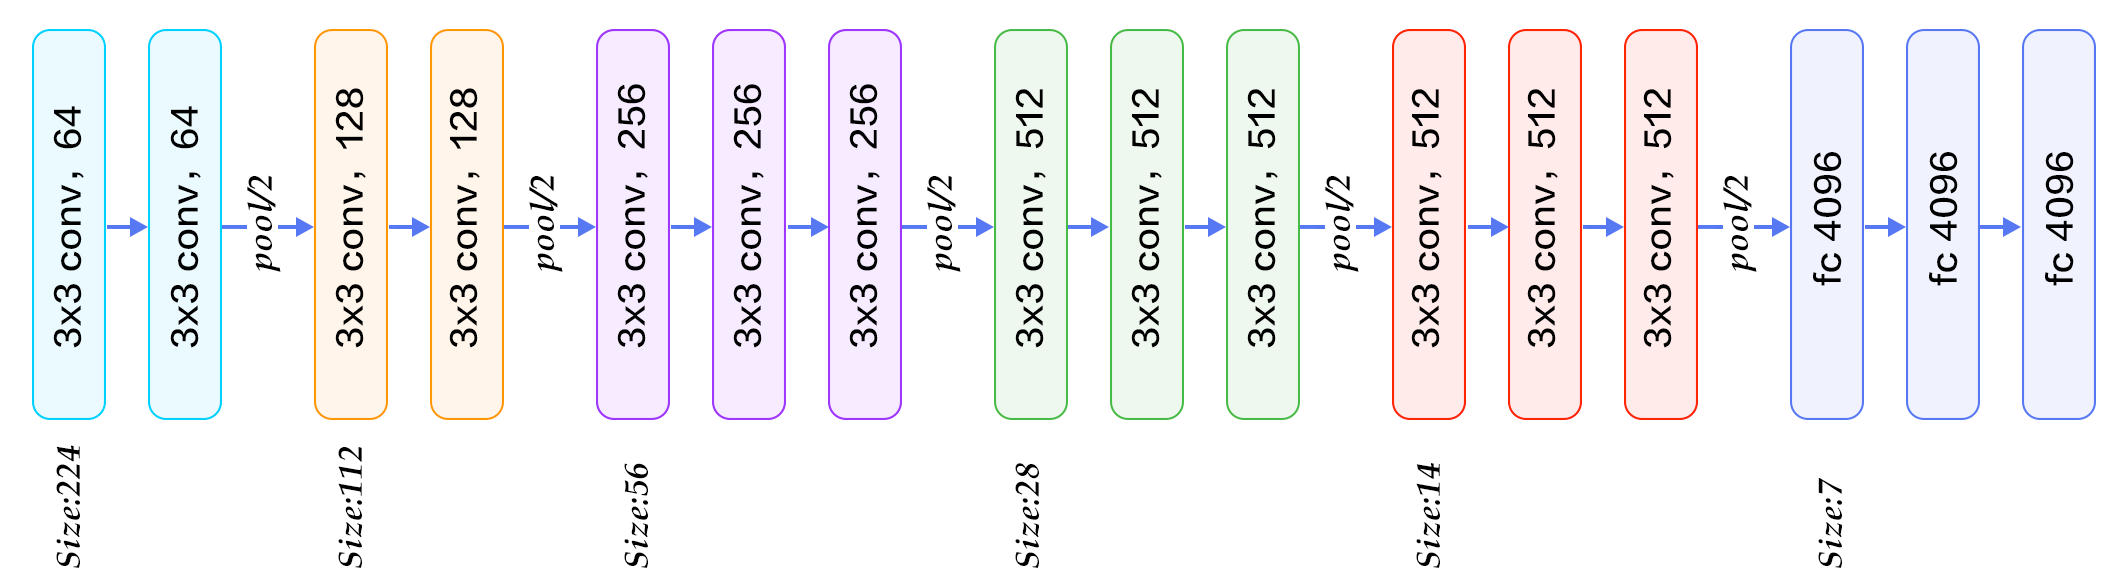

In [6]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/drive/MyDrive/NPTEL : Foundations of Deep Learning Concepts and Applications (Datasets)/vgg16_original.png')
cv2_imshow(img)

In [7]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import Flatten
from keras.layers import MaxPooling2D
from keras.layers import Dense
import numpy as np

In [8]:
from keras.src.ops.numpy import Max
# VGG-16 style model implemented as a Sequential model
# Matches the original VGG-16 block structure shown in the snippet

input_shape = (128, 128, 1)
num_classes = 4

model = Sequential()

# Block 1
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2, 2)))

# Block 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2, 2)))

# Block 4
model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Block 5
model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))

# Flatten the Layers
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(units=4096, activation='relu'))
model.add(Dense(units=4096, activation='relu'))

# Classifcation Head
model.add(Dense(units=num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   134,221,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,733,060 (632.22 MB)

 Trainable params: 165,733,060 (632.22 MB)

 Non-trainable params: 0 (0.00 B)

#### **Architecture Visualization**

In [22]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.8 MB/s eta 0:00:00


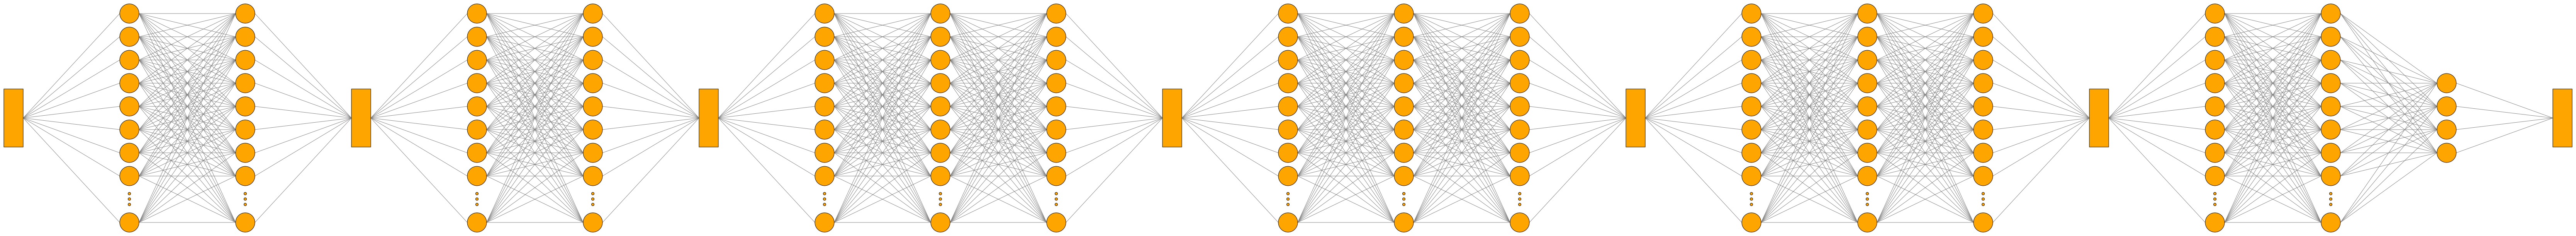

In [29]:
import visualkeras
from IPython.display import Image, display

visualkeras.graph_view(model, to_file='vgg16.png')
display(Image('vgg16.png', width=1200))

#### **Training**

In [30]:
model.fit(train_generator, epochs=50)

Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 75s 308ms/step - accuracy: 0.5836 - loss: 1.0286
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 29s 200ms/step - accuracy: 0.5935 - loss: 0.9826
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 29s 199ms/step - accuracy: 0.5935 - loss: 0.9808
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 29s 196ms/step - accuracy: 0.5935 - loss: 0.9786
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 30s 204ms/step - accuracy: 0.5935 - loss: 0.9795
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.5935 - loss: 0.9790
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 29s 199ms/step - accuracy: 0.5935 - loss: 0.9780
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 29s 200ms/step - accuracy: 0.5935 - loss: 0.9796
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 211ms/step - accuracy: 0.5935 - loss: 0.9793
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 39s 199ms/step - accuracy: 0.5935 - loss: 0.9771
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 40s 199ms/step - accuracy: 0.5935 - loss: 0.9778
Epoch 12/50
146/146

#### **Evaluation**

In [31]:
loss_1, accuracy_1 = model.evaluate(test_generator)
print(f"Accuracy:{accuracy_1}\nLoss:{loss_1}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.3756 - loss: 1.1976
Accuracy:0.37560975551605225
Loss:1.1975767612457275


### **VGG-19 Original**

#### **Model Architecture**

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

In [36]:
# Defining the Model
vgg19 = Sequential()

# Block 1
vgg19.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape))
vgg19.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Block 2
vgg19.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Block 3
vgg19.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Block 4
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Block 5
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
vgg19.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Flattening the Layers
vgg19.add(Flatten())

# Fully Connected Layers
vgg19.add(Dense(units=4096, activation='relu'))
vgg19.add(Dense(units=4096, activation='relu'))
vgg19.add(Dense(units=1000, activation='relu'))

# Classification Head
vgg19.add(Dense(units=4, activation='softmax'))

# Compiling the model
vgg19.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
vgg19.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1000)           │     4,097,00

 Total params: 74,464,076 (284.06 MB)

 Trainable params: 74,464,076 (284.06 MB)

 Non-trainable params: 0 (0.00 B)

#### **Architecture Visualization**

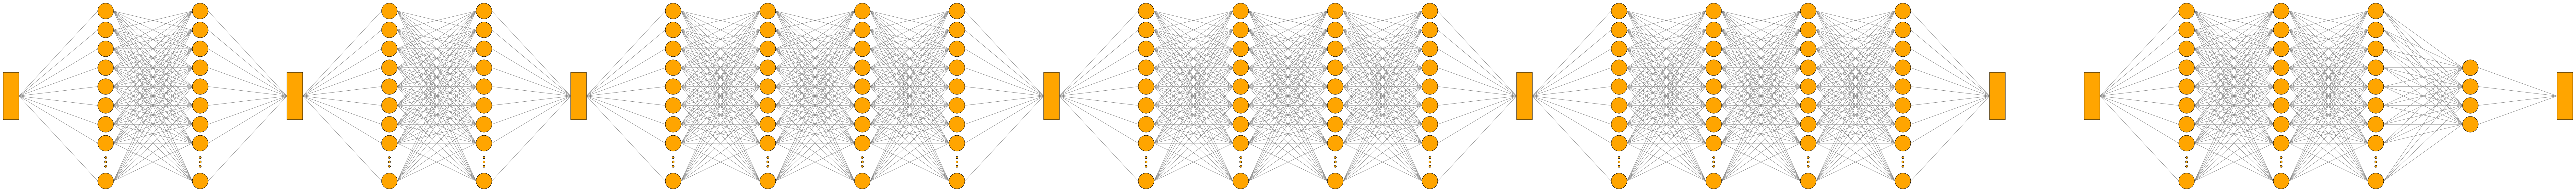

In [37]:
import visualkeras

visualkeras.graph_view(model=vgg19)

#### **Training**

In [38]:
vgg19.fit(train_generator, epochs=50, batch_size=64)

Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 48s 259ms/step - accuracy: 0.5793 - loss: 45.4090
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 33s 222ms/step - accuracy: 0.5935 - loss: 0.9864
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 221ms/step - accuracy: 0.5935 - loss: 0.9821
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 221ms/step - accuracy: 0.5935 - loss: 0.9798
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - accuracy: 0.5935 - loss: 0.9786
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 34s 232ms/step - accuracy: 0.5935 - loss: 0.9793
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.5935 - loss: 0.9789
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.5935 - loss: 0.9780
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.5935 - loss: 0.9788
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 34s 229ms/step - accuracy: 0.5935 - loss: 0.9745
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.5935 - loss: 0.9780
Epoch 12/50
146/14

#### **Evaluation**

In [39]:
loss_vgg19, accuracy_vgg19 = vgg19.evaluate(test_generator)
print(f"Accuracy:{accuracy_vgg19}\nLoss:{loss_vgg19}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.3756 - loss: 1.2274
Accuracy:0.37560975551605225
Loss:1.2274409532546997


We could have also used Dropout, BatchNormalization, Regularization and GlobalAveragePooling to make the model better.